# FocusMamba Overfit Probe

This notebook overfits `FocusMamba` on one training clip until **L1 loss < 0.1**, saves the model, and visualizes predictions on the same training sample.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

from dataloader.focus_dataset import FocusDataset
from models.focus_mamba import FocusMamba
from dataloader.focus_dataset import DataPrefetcher


torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


/home/wg19671/anaconda3/envs/focusmamba/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Build dataset and fetch one train clip
root = Path("./genfocus_data")
train_scenes = []
for scene_dir in sorted([d for d in root.iterdir() if d.is_dir()]):
    split_path = scene_dir / "split.txt"
    if split_path.exists() and split_path.read_text().strip().lower() == "train":
        train_scenes.append(scene_dir)

assert train_scenes, "No train scenes found"

ds = FocusDataset(
    scene_dirs=train_scenes,
    window_length=8,
    stride=4,
    crop_size=(256, 256),
    augment=False,
    max_coc=0.05,
    focal_length_range=(24.0, 85.0),
    aperture_range=(2.8, 10.0),
    beta_alpha=2.0,
    beta_beta=2.0,
    seed=42,
)

assert len(ds) > 0, "Dataset produced zero clips"
batch = ds[0]

frames = batch["frames"].unsqueeze(0).to(device)      # (1,3,T,H,W)
target = batch["focus_maps"].unsqueeze(0).to(device)  # (1,1,T,H,W)
roi = batch["roi"].unsqueeze(0).to(device)            # (1,4)

print("frames:", tuple(frames.shape))
print("target:", tuple(target.shape))
print("roi:", tuple(roi.shape))
print("metadata:", batch["metadata"])

frames: (1, 3, 8, 256, 256)
target: (1, 1, 8, 256, 256)
roi: (1, 4)
metadata: {'scene': 'bear', 'start_frame': 0, 'focal_length': 0.08370098848618732, 'aperture': 8.197382185561638, 's_focus': 5.09565870471736, 'focus_set': 'set_00', 'max_coc': 0.00038352893898263574}


In [5]:
model = FocusMamba().to(device)

# Reload saved model (optional sanity check) and run inference on training clip
ckpt = torch.load("./checkpoints/focus_mamba/best.pt", map_location="cpu")
model.load_state_dict(ckpt["model"])
model.to(device)
model.eval()

print(f"frames shape: {frames.shape}, roi shape: {roi.shape}")

with torch.no_grad():
    pred = model(frames, roi)

pred_cpu = pred.detach().cpu()[0, 0]      # (T,H,W)
target_cpu = target.detach().cpu()[0, 0]  # (T,H,W)
frames_cpu = frames.detach().cpu()[0]     # (3,T,H,W)

print("Prediction shape:", tuple(pred_cpu.shape))
print("Target shape:", tuple(target_cpu.shape))
print("Inference L1:", F.l1_loss(pred, target).item())

frames shape: torch.Size([1, 3, 8, 256, 256]), roi shape: torch.Size([1, 4])
Prediction shape: (8, 256, 256)
Target shape: (8, 256, 256)
Inference L1: 0.16760610044002533


In [ ]:
roi

tensor([[0.5561, 0.1170, 0.8462, 0.3634]], device='cuda:0')

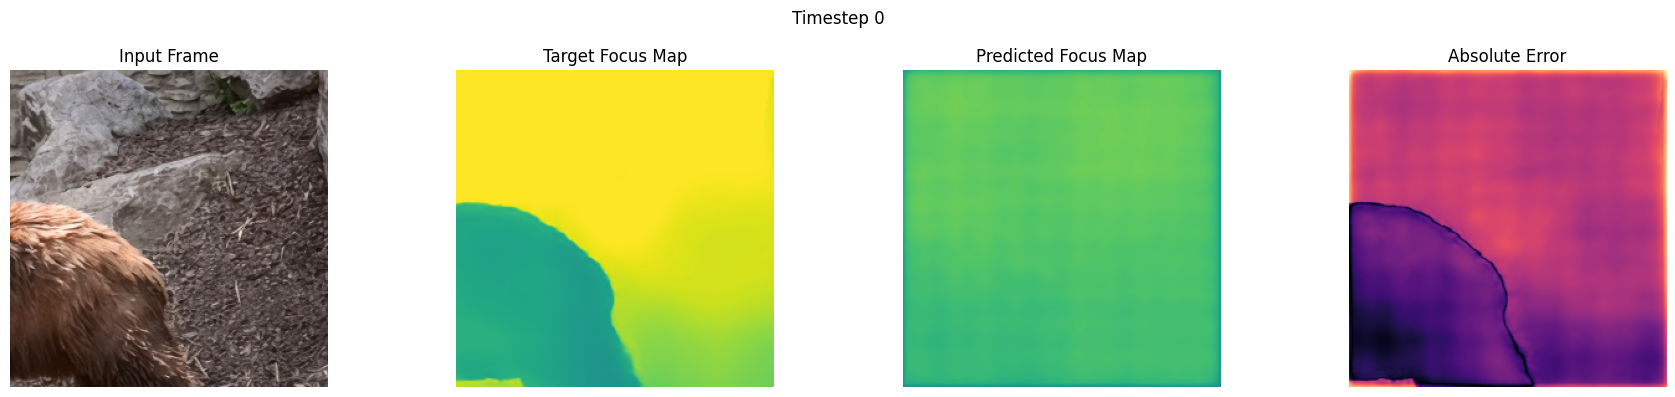

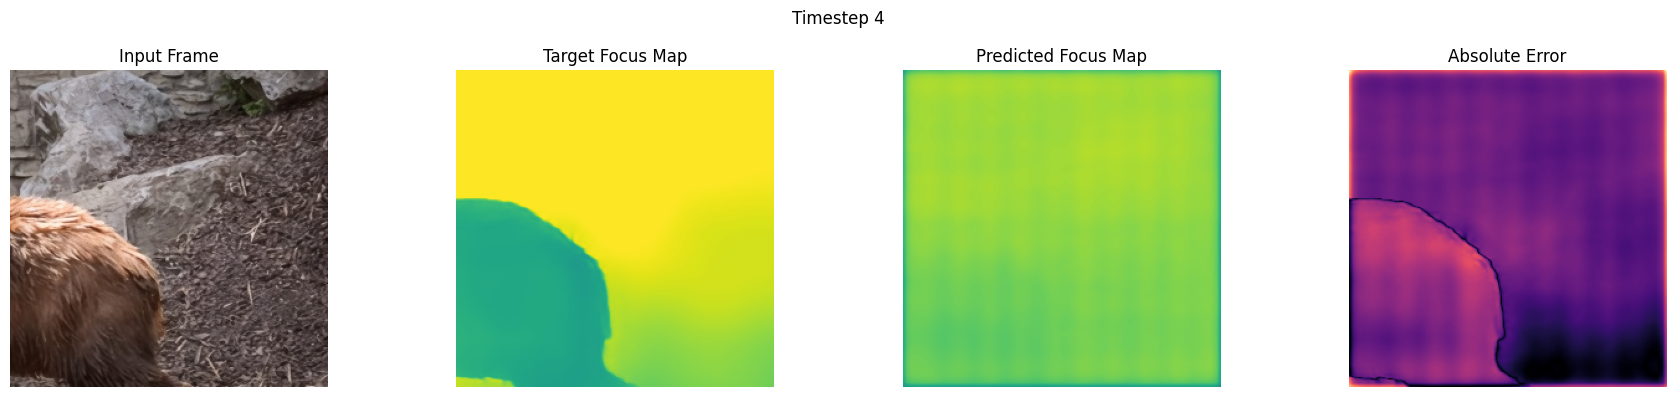

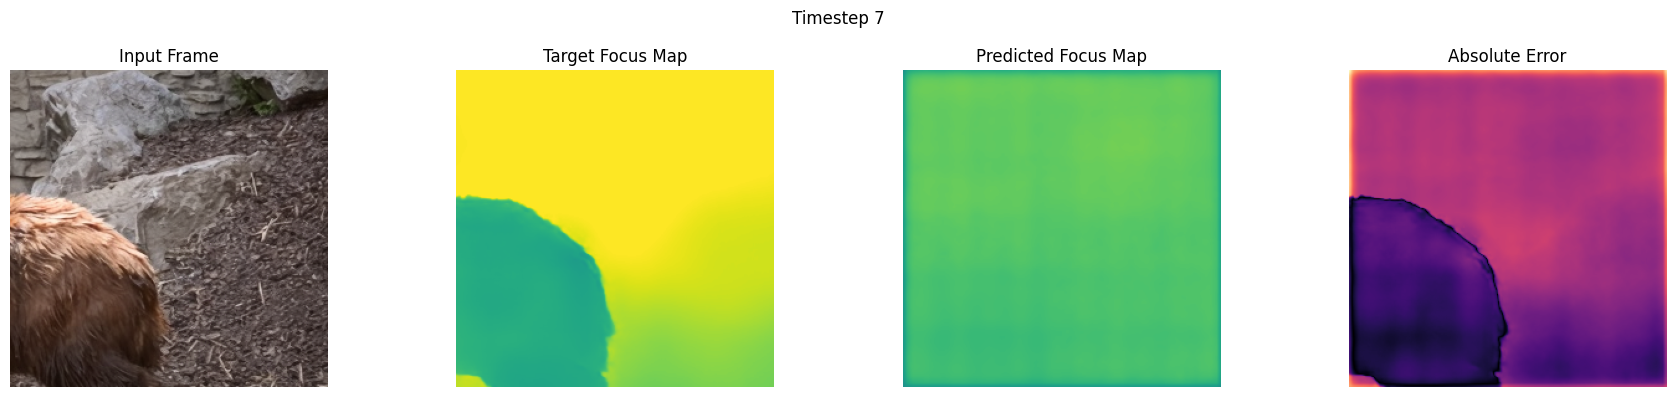

In [6]:
# Visualize model output vs target for selected timesteps
timesteps = [0, pred_cpu.shape[0] // 2, pred_cpu.shape[0] - 1]

for t in timesteps:
    frame_rgb = frames_cpu[:, t].permute(1, 2, 0).numpy()
    gt_map = target_cpu[t].numpy()
    pred_map = pred_cpu[t].numpy()
    err_map = np.abs(pred_map - gt_map)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f"Timestep {t}")

    axes[0].imshow(frame_rgb)
    axes[0].set_title("Input Frame")
    axes[0].axis("off")

    axes[1].imshow(gt_map, cmap="viridis", vmin=0.0, vmax=1.0)
    axes[1].set_title("Target Focus Map")
    axes[1].axis("off")

    axes[2].imshow(pred_map, cmap="viridis", vmin=0.0, vmax=1.0)
    axes[2].set_title("Predicted Focus Map")
    axes[2].axis("off")

    axes[3].imshow(err_map, cmap="magma")
    axes[3].set_title("Absolute Error")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()